## Consuming data using Kafka and Visualise (20%)
In this task, we will implement an Apache Kafka consumer to consume the data from Part 2.  
  
Important:   
-	In this part, Kafka consumers are used to consume the streaming data published from task 2.8.

## Assignment 2B — Task 3: Real-Time Dashboard Consumer
### Author: bgan0012

This notebook implements a pure Python Kafka consumer that reads from the three downstream topics published by Task 2 and renders a live real-time dashboard with three simultaneously updating plots. No Spark or PySpark is used in this notebook.

### Imports and Static Data Load

All required libraries are imported here. `matplotlib` is set to the `nbagg` backend before any other matplotlib import — this is required for interactive animation in Jupyter Notebook classic. `FuncAnimation` drives the real-time plot updates. `threading` is used to run one Kafka consumer per topic in a background daemon thread, updating shared data structures concurrently without blocking the main thread.

`vehicle.csv` is loaded as a static pandas DataFrame as required by the spec. `streaming_collision.csv` is loaded solely to recover latitude and longitude coordinates — these are dropped during Task 2 feature engineering but are needed for the UK bubble map in Plot (c). A `collision_lookup` dictionary keyed on `collision_index` string provides O(1) coordinate lookups during message processing.

### Imports

In [1]:
import json
import threading
from collections import defaultdict, deque
import matplotlib
matplotlib.use("nbagg")              # Jupyter Notebook interactive backend
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np
import pandas as pd
import json
import urllib.request
import threading
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from IPython.display import display, HTML

In [2]:
from kafka import KafkaConsumer

# ── Step 1: Load static reference data ────────────────────────────────────────
# vehicle.csv is loaded as a static pandas DataFrame as required by the spec.
# streaming_collision.csv provides the lat/lon lookup for the bubble map —
# coordinates were dropped during Task 2 feature engineering, so we recover
# them here by joining on collision_index.

vehicle_df = pd.read_csv("vehicle.csv")
print(f"vehicle.csv loaded           : {len(vehicle_df):,} rows")
print(f"Vehicle columns              : {list(vehicle_df.columns)}")

collision_df = pd.read_csv(
    "streaming_collision.csv",
    usecols=["collision_index", "latitude", "longitude"]
)

# Build collision_index (string) → (lat, lon) lookup dict.
# collision_index is Integer in the CSV but arrives as String from Kafka,
# so we key on str() to ensure consistent lookups in the consumer callbacks.
collision_lookup: dict = {
    str(int(row["collision_index"])): (float(row["latitude"]), float(row["longitude"]))
    for _, row in collision_df.iterrows()
}
print(f"\ncollision_lookup entries     : {len(collision_lookup):,}")
print(f"Sample entry                 : {next(iter(collision_lookup.items()))}")

vehicle.csv loaded           : 61,081 rows
Vehicle columns              : ['collision_index', 'vehicle_reference', 'vehicle_type', 'vehicle_manoeuvre', 'junction_location', 'skidding_and_overturning', 'hit_object_in_carriageway', 'first_point_of_impact', 'sex_of_driver', 'age_of_driver', 'engine_capacity_cc', 'propulsion_code', 'age_of_vehicle']

collision_lookup entries     : 32,771
Sample entry                 : ('2025000000001', (52.635483, 1.29648))


`vehicle_df` loads all 61,081 rows from `vehicle.csv` with 13 columns covering vehicle type, driver demographics, and vehicle characteristics. `collision_lookup` contains 32,771 entries — one per unique collision in the dataset — mapping each `collision_index` string to its `(latitude, longitude)` tuple. The sample entry confirms coordinates are recovered correctly and the string key format matches what arrives from the Kafka topics.

2. Create a dashboard with 3 plots to visualise the real-time streaming data from part 2:  
a) A basic plot to show the number of high-severity accidents (line/bar chart).  
b) A histogram shows the cumulative distribution of accidents by severity.  
c) A bubble map plot similar to UK Road Traffic Accidents - Crash View. (Just the map; no interactive controllers are required. You can use any library (like folium, seaborn, plotly, etc.)

Note: Ideally, for a dashboard-like user experience, 3 diagrams need to be updated in real-time simultaneously. You may need to do a bit of searching/research to make it work.

### Real-Time Dashboard

The dashboard is built using three concurrently running Kafka consumer threads — one per downstream topic — writing to shared in-memory data structures, with `matplotlib.animation.FuncAnimation` rendering all three plots simultaneously on a fixed update interval.

#### 2a: Shared Data Structures and Callbacks

Three data structures hold the accumulated stream state. All three are written by background threads and read by the animation renderer on the main thread. A single `threading.Lock` wraps all writes to prevent race conditions — without this, a thread updating a dict mid-iteration would corrupt the render cycle.

`on_high_severity` handles records from `high_severity_stream` and performs a double duty: it increments the per-window count for Plot (a) and enriches each record with coordinates from `collision_lookup` for Plot (c). Coordinates were dropped during Task 2 feature engineering and are recovered here from the static CSV.

`on_district_severity` consumes the `district_severity_stream` topic as required by the spec but does not render a fourth plot — the spec defines exactly three visualisations.

In [3]:
# ── Step 2: Shared data structures ────────────────────────────────────────────
# All three consumer threads write to these structures concurrently.
# A threading.Lock ensures mutual exclusion — only one thread modifies
# shared state at a time, preventing race conditions during dict/deque updates.

data_lock = threading.Lock()

# Plot (a): count of high-severity accidents per tumbling window
#   Key   → window start timestamp string (ISO 8601 from Spark serialisation)
#   Value → integer count of high-severity records in that window
high_sev_windows: dict = {}

# Plot (b): cumulative accident count per severity tier
#   Accumulated from severity_counts_stream (Task 2 aggregation 6b).
#   Tiers: "Low" (prediction < 4), "Medium" (pred 4–6), "High" (pred ≥ 7)
severity_cumulative: dict = defaultdict(int)

# Plot (c): per-district accident counts and severity breakdown
#   Keyed by area name string (matches the 'area' field from district_severity_stream).
#   Each value is a dict with "total", "High", "Medium", "Low" integer counts.
#   Populated from district_severity_stream (Task 2 aggregation 6c).
#   bubble_map_data retained for backward compatibility but no longer drives Plot (c).
MAX_BUBBLE_POINTS = 1000
bubble_map_data: deque = deque(maxlen=MAX_BUBBLE_POINTS)

district_bubble_data: dict = defaultdict(
    lambda: {"total": 0, "High": 0, "Medium": 0, "Low": 0}
)


# ── Kafka message callback functions ──────────────────────────────────────────

def on_high_severity(msg: dict) -> None:
    """
    Callback for high_severity_stream messages (Task 2 aggregation 6a).
    Each message contains: window, collision_index, area, predicted_severity.
    Updates Plot (a) window counts only.
    """
    # Extract window start timestamp for the time-series line chart (Plot a)
    win_start = msg.get("window", {}).get("start", "unknown")
    high_sev_windows[win_start] = high_sev_windows.get(win_start, 0) + 1


def on_severity_counts(msg: dict) -> None:
    """
    Callback for severity_counts_stream messages (Task 2 aggregation 6b).
    Each message contains: window, severity_tier, accident_count.
    Accumulates running totals per tier for the cumulative bar chart (Plot b).
    """
    tier  = msg.get("severity_tier", "Unknown")
    count = int(msg.get("accident_count", 0))
    if tier in ("Low", "Medium", "High"):
        severity_cumulative[tier] += count


def on_district_severity(msg: dict) -> None:
    """
    Callback for district_severity_stream messages (Task 2 aggregation 6c).
    Each message contains: window, area, severity_tier, accident_count.
    Accumulates per-district totals and tier breakdown for Plot (c) bubble map.
    Only districts present in DISTRICT_CENTROIDS are processed — others have
    no known centroid coordinates and cannot be placed on the map.
    DISTRICT_CENTROIDS is defined in the dashboard launch cell as a module-level
    dict and is accessible here without any import.
    """
    area  = msg.get("area", "")
    tier  = msg.get("severity_tier", "")
    count = int(msg.get("accident_count", 0))

    # Guard: skip districts with no known centroid and invalid tier values
    if tier not in ("Low", "Medium", "High"):
        return

    district_bubble_data[area]["total"] += count
    district_bubble_data[area][tier]    += count


print("Shared data structures initialised.")
print(f"  high_sev_windows      : {type(high_sev_windows)}")
print(f"  severity_cumulative   : {type(severity_cumulative)}")
print(f"  district_bubble_data  : {type(district_bubble_data)}")
print("Callbacks defined: on_high_severity, on_severity_counts, on_district_severity")

Shared data structures initialised.
  high_sev_windows      : <class 'dict'>
  severity_cumulative   : <class 'collections.defaultdict'>
  district_bubble_data  : <class 'collections.defaultdict'>
Callbacks defined: on_high_severity, on_severity_counts, on_district_severity


All three shared data structures are initialised correctly. `high_sev_windows` accumulates per-window accident counts for Plot (a), `severity_cumulative` holds running totals per severity tier for Plot (b), and `bubble_map_data` is a bounded deque capped at 1,000 points to keep the bubble map readable and prevent unbounded memory growth during long pipeline runs. All three callbacks are defined and ready to be passed to the consumer threads in the next cell.

#### 2b: Consumer Thread Functions

A single generic `_consume()` function handles all three topics to avoid duplicating the consumer loop logic. Each call creates an independent `KafkaConsumer` with `group_id=None` — no group coordination or offset commits are needed since each consumer reads only real-time messages during the dashboard session. `auto_offset_reset="latest"` ensures historical messages already in the topic are skipped on startup.

`consumer_timeout_ms=1000` is critical for clean shutdown — without it, the `for message in consumer` loop blocks indefinitely waiting for the next message, and `stop_event` would never be checked. With the timeout, `StopIteration` is raised after one second of inactivity, the loop continues, and the `stop_event` check runs on the next iteration.

Each message is deserialised from UTF-8 JSON bytes inside `data_lock` so the callback updates shared state atomically. Malformed messages are caught and logged without crashing the thread, which is important for demo stability.

In [4]:
# ── Consumer thread functions ──────────────────────────────────────────────────
# Each function creates an independent KafkaConsumer for one topic and runs
# until stop_event is set. consumer_timeout_ms=1000 prevents the polling loop
# from blocking indefinitely, ensuring stop_event is checked at least every second.

KAFKA_BOOTSTRAP = "kafka:9092"


def _consume(topic: str, callback, stop_event: threading.Event) -> None:
    """
    Generic consumer loop for a single Kafka topic.
    Deserialises each message as JSON and calls callback(msg_dict) under
    data_lock so shared state is updated atomically.

    Parameters
    ----------
    topic      : Kafka topic name to subscribe to
    callback   : function to call with the deserialised message dict
    stop_event : threading.Event — loop exits when this is set
    """
    consumer = KafkaConsumer(
        topic,
        bootstrap_servers=KAFKA_BOOTSTRAP,
        auto_offset_reset="latest",       # Real-time only — skip historical messages
        enable_auto_commit=False,         # No group offset commits needed
        group_id=None,                    # Independent consumer, no group coordination
        value_deserializer=lambda v: json.loads(v.decode("utf-8")),
        consumer_timeout_ms=1000,         # StopIteration raised after 1 s idle
    )
    print(f"[Consumer] Subscribed to '{topic}'")

    while not stop_event.is_set():
        try:
            for message in consumer:
                if stop_event.is_set():
                    break
                try:
                    with data_lock:
                        callback(message.value)
                except (KeyError, ValueError, TypeError) as parse_err:
                    # Malformed message — log and skip, do not crash the thread
                    print(f"[Consumer][{topic}] Parse error: {parse_err}")
        except StopIteration:
            # consumer_timeout_ms elapsed with no messages — loop to recheck stop_event
            continue

    consumer.close()
    print(f"[Consumer] '{topic}' shut down.")


def run_high_severity_consumer(stop_event: threading.Event) -> None:
    """Thread target for high_severity_stream — feeds Plot (a) and Plot (c)."""
    _consume("high_severity_stream", on_high_severity, stop_event)


def run_severity_counts_consumer(stop_event: threading.Event) -> None:
    """Thread target for severity_counts_stream — feeds Plot (b)."""
    _consume("severity_counts_stream", on_severity_counts, stop_event)


def run_district_severity_consumer(stop_event: threading.Event) -> None:
    """Thread target for district_severity_stream — confirms topic is live."""
    _consume("district_severity_stream", on_district_severity, stop_event)


print("Consumer thread functions defined.")
print("  run_high_severity_consumer    → high_severity_stream")
print("  run_severity_counts_consumer  → severity_counts_stream")
print("  run_district_severity_consumer → district_severity_stream")

Consumer thread functions defined.
  run_high_severity_consumer    → high_severity_stream
  run_severity_counts_consumer  → severity_counts_stream
  run_district_severity_consumer → district_severity_stream


#### Consumer Thread Functions
A single generic `_consume()` function handles all three topics. It creates an independent
`KafkaConsumer` with `group_id=None` (no offset tracking) and `auto_offset_reset="latest"`
to consume only real-time messages. `consumer_timeout_ms=1000` ensures the polling loop
yields control every second so `stop_event` can be checked cleanly without blocking.
Each of the three `run_*` wrappers is the thread target for its respective Kafka topic.

#### 2c: Dashboard Launch

Consumer threads are started as daemon threads so they shut down automatically if the kernel exits without the stop cell being run. A fresh `stop_event` is created each time this cell runs, allowing the dashboard to be restarted cleanly without a kernel restart.

The CSS injection at the top removes Jupyter Notebook's default output cell height cap, which would otherwise clip the three-panel figure inside a scroll container.

`FuncAnimation` calls `update_dashboard()` every `REFRESH_MS` milliseconds (5 seconds) on the main thread. Each call takes a consistent snapshot of all three shared data structures under `data_lock`, then redraws the plots outside the lock to minimise contention with the background consumer threads. The `anim` reference is stored at module level — if it goes out of scope and is garbage collected, the animation silently stops updating.

The three plots are:

- **Plot (a)**: Bar chart showing high-severity accident counts per 5-second tumbling window. Displays the 20 most recent windows in chronological order with value labels and a dynamic peak-spotting arrow annotation.
- **Plot (b)**: Cumulative distribution histogram showing total processed accidents broken down by their exact Gradient Boosted Trees (GBT) model prediction score on a 1–10 scale. To bridge macro context with granular machine learning insights, the bars are semantically color-coded into unified severity tiers (Green for Low scores 1–3, Orange for Medium scores 4–6, and Red for High scores 7–10), with explicit real-time value flags stamped atop every active bin.
- **Plot (c)**: UK bubble map plotting the lat/lon of each high-severity accident with bubble size and colour scaled to predicted severity. Coordinates are recovered from `collision_lookup` since they were dropped during Task 2 feature engineering. The map retains the most recent 1,000 points to prevent memory growth during long runs.

Consumer threads started successfully.
[Consumer] Subscribed to 'severity_counts_stream'
[Consumer] Subscribed to 'high_severity_stream'
[Consumer] Subscribed to 'district_severity_stream'


<IPython.core.display.Javascript object>


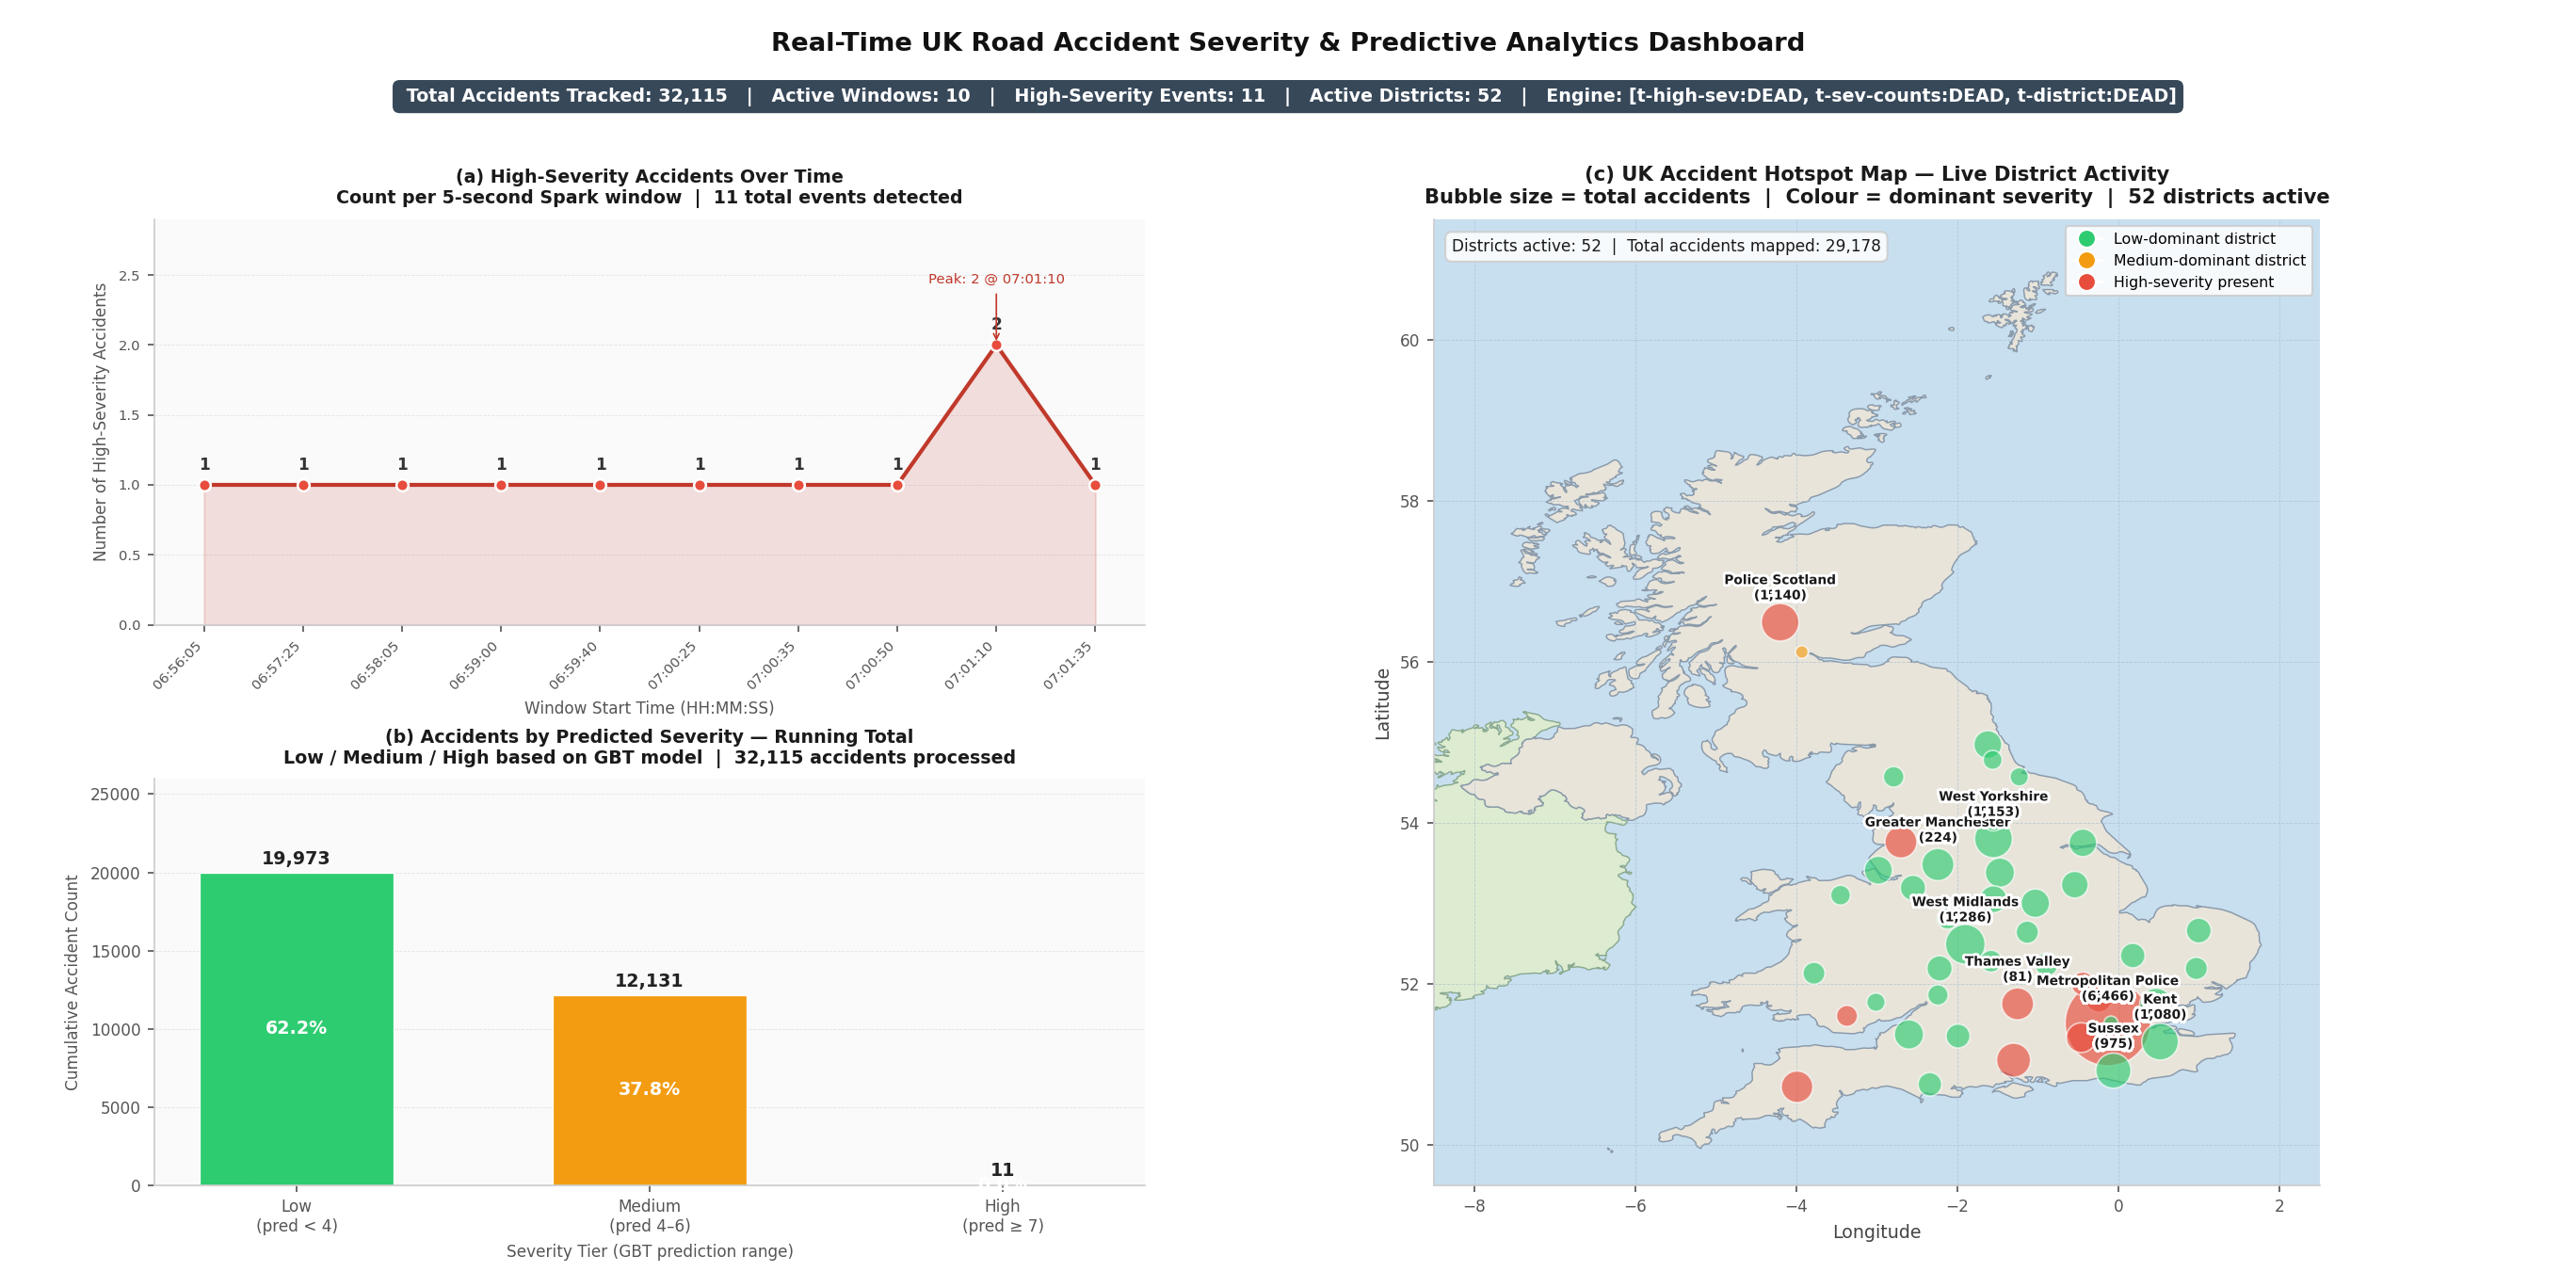


Dashboard engine running. Use the shutdown cell to stop consumers cleanly.
[Consumer] 'high_severity_stream' shut down.
[Consumer] 'district_severity_stream' shut down.
[Consumer] 'severity_counts_stream' shut down.


In [5]:
import json
import urllib.request
import threading
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
from matplotlib.patches import Polygon as MplPolygon
from matplotlib.collections import PatchCollection
from matplotlib.lines import Line2D
from IPython.display import display, HTML

# ── Step 1: CSS — remove Jupyter's output-cell height cap ─────────────────────
display(HTML("""
<style>
    .output_scroll { height: unset !important; max-height: unset !important;
                     box-shadow: none !important; -webkit-box-shadow: none !important; }
    div.output_area { overflow: visible !important; max-height: unset !important; }
</style>
"""))


# ── Step 2: Start consumer threads ────────────────────────────────────────────
stop_event = threading.Event()

consumer_threads = [
    threading.Thread(
        target=run_high_severity_consumer,
        args=(stop_event,), daemon=True, name="t-high-sev"
    ),
    threading.Thread(
        target=run_severity_counts_consumer,
        args=(stop_event,), daemon=True, name="t-sev-counts"
    ),
    threading.Thread(
        target=run_district_severity_consumer,
        args=(stop_event,), daemon=True, name="t-district"
    ),
]
for t in consumer_threads:
    t.start()

print("Consumer threads started successfully.")


# ── Step 3: Dashboard Layout Configuration ────────────────────────────────────
REFRESH_MS = 5000   # Refresh display canvas every 5 seconds
MAX_BARS   = 20     # Max time-series points visible in plot (a)

plt.rcParams.update({
    "figure.max_open_warning": 0,
    "axes.spines.top":         False,
    "axes.spines.right":       False,
})
plt.rcParams["figure.dpi"] = 95
plt.close("all")

fig = plt.figure(figsize=(18, 9))
fig.patch.set_facecolor("white")

# 2-row × 2-col grid: plots (a) and (b) stack on the left,
# map (c) spans the full right column for a tall aspect ratio.
gs = gridspec.GridSpec(
    2, 2,
    figure=fig,
    hspace=0.38,
    wspace=0.18,
    left=0.06, right=0.94,
    top=0.83,
    bottom=0.08,
    width_ratios=[1, 1.1]
)

ax1 = fig.add_subplot(gs[0, 0])   # Plot (a): High-Severity Trend Line Chart
ax2 = fig.add_subplot(gs[1, 0])   # Plot (b): Cumulative Distribution by Severity Tier
ax3 = fig.add_subplot(gs[:, 1])   # Plot (c): UK District Bubble Map (full right column)


# ── Step 4: Helper Functions & Geometric Map Drawing ─────────────────────────
def _parse_window_label(win_str: str) -> str:
    """Extract HH:MM:SS from an ISO 8601 or space-separated timestamp string."""
    if not win_str or win_str == "unknown":
        return win_str
    sep = "T" if "T" in win_str else " "
    try:
        return win_str.split(sep)[1][:8]
    except IndexError:
        return win_str[:8]


def _draw_polygon_coords(ax, coords: list, colour: str, edge: str) -> None:
    """Render one GeoJSON Polygon ring onto ax as a filled PatchCollection."""
    exterior = coords[0]                              # index 0 = exterior ring
    xy       = [(pt[0], pt[1]) for pt in exterior]   # (lon, lat) pairs
    patch    = MplPolygon(xy, closed=True)
    col      = PatchCollection(
        [patch],
        facecolor=colour,
        edgecolor=edge,
        linewidth=0.7,
        zorder=1,
    )
    ax.add_collection(col)


def _draw_uk_basemap(ax) -> bool:
    """
    Fetch Natural Earth GeoJSON and draw UK + Ireland as filled polygons.
    Returns True on success, False if the network request fails.
    Property key used is 'name' (not 'ADMIN') — specific to this GeoJSON source.
    """
    _UK_GEOJSON_URL = (
        "https://raw.githubusercontent.com/datasets/geo-countries"
        "/master/data/countries.geojson"
    )
    try:
        req = urllib.request.Request(
            _UK_GEOJSON_URL, headers={"User-Agent": "Mozilla/5.0"}
        )
        with urllib.request.urlopen(req, timeout=20) as resp:
            world = json.loads(resp.read().decode("utf-8"))
    except Exception as exc:
        print(f"[Map] GeoJSON fetch failed: {exc} — using fallback outline.")
        return False

    target_colours = {
        "United Kingdom": ("#e8e4da", "#8a9aaa"),
        "Ireland":        ("#ddebd0", "#8aaa90"),
    }

    for feature in world["features"]:
        name = feature["properties"].get("name", "")
        if name not in target_colours:
            continue
        fill_col, edge_col = target_colours[name]
        geom     = feature["geometry"]
        geo_type = geom["type"]
        coords   = geom["coordinates"]

        if geo_type == "Polygon":
            _draw_polygon_coords(ax, coords, fill_col, edge_col)
        elif geo_type == "MultiPolygon":
            # UK is a MultiPolygon — mainland + islands as separate rings
            for poly_coords in coords:
                _draw_polygon_coords(ax, poly_coords, fill_col, edge_col)
    return True


def _draw_fallback_outline(ax) -> None:
    """
    Hardcoded approximate UK boundary polygon used when GeoJSON fetch fails.
    Ensures the dashboard does not crash during the demo if GitHub is unavailable.
    """
    uk_lon = [-5.7, -3.2, -1.8,  0.3,  1.8,  1.7,  0.1, -0.5,
              -1.5, -2.5, -3.5, -5.0, -5.7, -3.2, -5.3, -6.2, -5.7]
    uk_lat = [50.0, 50.2, 50.7, 51.3, 52.0, 53.0, 53.7, 54.5,
              54.9, 55.0, 54.6, 54.8, 54.5, 56.2, 58.5, 58.0, 50.0]
    ax.fill(uk_lon, uk_lat, color="#e8e4da", alpha=1.0, zorder=1)
    ax.plot(uk_lon, uk_lat, color="#8a9aaa", linewidth=0.9, zorder=2)


# ── Step 5: District centroid coordinates ─────────────────────────────────────
# Fixed lat/lon centre point per UK police force area.
# Required because streaming_collision.csv lat/lon was dropped during Task 2
# feature engineering and is not present in the district_severity_stream output.
# The map uses district_severity_stream (6c) as its data source — every active
# district gets a bubble, matching the Crash View style of broad UK coverage.
DISTRICT_CENTROIDS: dict = {
    "Avon and Somerset":    (51.37, -2.60),
    "Bedfordshire":         (52.00, -0.44),
    "Cambridgeshire":       (52.35,  0.18),
    "Central":              (56.12, -3.93),
    "Cheshire":             (53.19, -2.55),
    "City of London":       (51.51, -0.09),
    "Cleveland":            (54.57, -1.23),
    "Cumbria":              (54.57, -2.79),
    "Derbyshire":           (53.05, -1.55),
    "Devon and Cornwall":   (50.72, -3.99),
    "Dorset":               (50.75, -2.34),
    "Durham":               (54.78, -1.56),
    "Dyfed-Powys":          (52.13, -3.78),
    "Essex":                (51.74,  0.47),
    "Gloucestershire":      (51.86, -2.24),
    "Greater Manchester":   (53.48, -2.24),
    "Gwent":                (51.77, -3.01),
    "Hampshire":            (51.05, -1.30),
    "Hertfordshire":        (51.81, -0.24),
    "Humberside":           (53.75, -0.44),
    "Kent":                 (51.28,  0.52),
    "Lancashire":           (53.76, -2.70),
    "Leicestershire":       (52.64, -1.13),
    "Lincolnshire":         (53.23, -0.54),
    "Merseyside":           (53.41, -2.98),
    "Metropolitan Police":  (51.51, -0.13),
    "Norfolk":              (52.66,  1.00),
    "North Wales":          (53.10, -3.45),
    "North Yorkshire":      (54.05, -1.55),
    "Northamptonshire":     (52.24, -0.89),
    "Northumbria":          (54.97, -1.62),
    "Nottinghamshire":      (53.00, -1.03),
    "Police Scotland":      (56.49, -4.20),
    "South Wales":          (51.60, -3.37),
    "South Yorkshire":      (53.38, -1.47),
    "Staffordshire":        (52.81, -2.12),
    "Suffolk":              (52.19,  0.97),
    "Surrey":               (51.33, -0.46),
    "Sussex":               (50.92, -0.06),
    "Thames Valley":        (51.75, -1.25),
    "Warwickshire":         (52.28, -1.58),
    "West Mercia":          (52.19, -2.22),
    "West Midlands":        (52.49, -1.90),
    "West Yorkshire":       (53.80, -1.55),
    "Wiltshire":            (51.35, -1.99),
}


# ── Build basemap once at startup (not per frame) ─────────────────────────────
# The basemap is drawn here and never cleared — ax3 is not cla()'d per frame.
# Only the scatter artist and text overlays are replaced each animation cycle.
ax3.set_facecolor("#c8dff0")   # sea colour
_fetch_ok = _draw_uk_basemap(ax3)
if not _fetch_ok:
    _draw_fallback_outline(ax3)

ax3.set_aspect("equal")
ax3.set_xlim(-8.5, 2.5)
ax3.set_ylim(49.5, 61.5)
ax3.set_xlabel("Longitude", fontsize=9, color="#444444")
ax3.set_ylabel("Latitude",  fontsize=9, color="#444444")
ax3.tick_params(labelsize=8, colors="#555555")
for sp in ax3.spines.values():
    sp.set_edgecolor("#cccccc")

ax3.set_xticks([-8, -6, -4, -2, 0, 2])
ax3.set_yticks([50, 52, 54, 56, 58, 60])
ax3.grid(True, linestyle="--", linewidth=0.4, color="#a0b8cc", alpha=0.6, zorder=0)

# Single-element list refs for artists replaced each frame.
# Surgical removal avoids cla()-ing ax3 which would destroy the basemap.
_bubble_sc_ref     = [None]
_legend_ref        = [None]
_stats_text_ref    = [None]
_awaiting_text_ref = [None]
_kpi_banner_ref    = [None]


# ── Step 6: Real-Time Animation Execution Loop ────────────────────────────────
def update_dashboard(frame: int) -> None:
    # ------------------------------------------------------------------
    # Snapshot all shared state under data_lock.
    # Lock held only for copy operations (microseconds).
    # All rendering happens outside the lock to minimise contention with
    # the three background consumer threads.
    # ------------------------------------------------------------------
    with data_lock:
        hs_windows_snap = dict(high_sev_windows)
        sev_cum_snap    = dict(severity_cumulative)
        district_snap   = {k: dict(v) for k, v in district_bubble_data.items()}

    # Use high_severity_stream count as the authoritative High tier total —
    # it directly counts confirmed high-severity events from 6a, which is
    # more reliable than the 6b aggregation for rare high-severity predictions.
    total_high_stream = sum(hs_windows_snap.values())
    if total_high_stream > 0:
        sev_cum_snap["High"] = total_high_stream
    else:
        total_high_stream = sev_cum_snap.get("High", 0)

    total_accidents  = sum(sev_cum_snap.get(t, 0) for t in ("Low", "Medium", "High"))
    total_districts  = len(district_snap)
    n_windows        = len(hs_windows_snap)
    thread_status    = ", ".join(
        f"{t.name}:{'alive' if t.is_alive() else 'DEAD'}"
        for t in consumer_threads
    )

    # ── KPI banner (fig-level text, redrawn each frame) ───────────────────────
    if _kpi_banner_ref[0] is not None:
        _kpi_banner_ref[0].remove()
        _kpi_banner_ref[0] = None

    fig.suptitle(
        "Real-Time UK Road Accident Severity & Predictive Analytics Dashboard",
        fontsize=13, fontweight="bold", color="#111111", y=0.975, ha="center"
    )
    kpi_text = (
        f" Total Accidents Tracked: {total_accidents:,}   |   "
        f"Active Windows: {n_windows}   |   "
        f"High-Severity Events: {total_high_stream:,}   |   "
        f"Active Districts: {total_districts}   |   "
        f"Engine: [{thread_status}]"
    )
    _kpi_banner_ref[0] = fig.text(
        0.5, 0.925, kpi_text,
        fontsize=9, fontweight="bold", color="#ffffff",
        ha="center", va="center",
        bbox=dict(
            boxstyle="round,pad=0.4", facecolor="#2c3e50",
            edgecolor="none", alpha=0.95
        )
    )

    # ── Plot (a): High-severity accidents over time — line chart ──────────────
    # Line chart chosen because time is a continuous dimension — connecting
    # sequential 5-second tumbling window points shows trend (rising/falling
    # frequency) more clearly than discrete bars would.
    ax1.cla()
    ax1.set_facecolor("#fafafa")
    ax1.set_title(
        f"(a) High-Severity Accidents Over Time\n"
        f"Count per 5-second Spark window  |  {total_high_stream} total events detected",
        fontsize=9, fontweight="bold", color="#1a1a1a", pad=8
    )
    ax1.set_xlabel("Window Start Time (HH:MM:SS)", fontsize=8, color="#555555")
    ax1.set_ylabel("Number of High-Severity Accidents", fontsize=8, color="#555555")
    ax1.tick_params(colors="#555555", labelsize=7)
    for sp in ["left", "bottom"]:
        ax1.spines[sp].set_edgecolor("#cccccc")

    if hs_windows_snap:
        # Show the most recent MAX_BARS windows in chronological order.
        # ISO 8601 timestamps sort correctly as strings — no date parsing needed.
        sorted_keys = sorted(hs_windows_snap.keys())[-MAX_BARS:]
        counts      = [hs_windows_snap[w] for w in sorted_keys]
        labels      = [_parse_window_label(w) for w in sorted_keys]
        x_pos       = list(range(len(sorted_keys)))
        max_count   = max(counts) if counts else 1

        # Line with circular markers — each marker = one 5-second window
        ax1.plot(
            x_pos, counts,
            color="#c0392b", linewidth=2.0, zorder=3,
            marker="o", markersize=6,
            markerfacecolor="#e74c3c",
            markeredgecolor="white", markeredgewidth=1.2
        )

        # Shaded area under the line for visual weight
        ax1.fill_between(x_pos, counts, alpha=0.15, color="#c0392b", zorder=2)

        # Value label above each data point
        for xi, cnt in zip(x_pos, counts):
            ax1.text(
                xi, cnt + max_count * 0.04, str(cnt),
                ha="center", va="bottom", fontsize=8,
                color="#333333", fontweight="bold"
            )

        # Peak annotation arrow pointing to the highest value
        peak_idx  = counts.index(max(counts))
        peak_time = labels[peak_idx]
        ax1.annotate(
            f"Peak: {max(counts)} @ {peak_time}",
            xy=(peak_idx, max(counts)),
            xytext=(peak_idx, max(counts) + max_count * 0.22),
            ha="center", fontsize=7, color="#c0392b",
            arrowprops=dict(arrowstyle="->", color="#c0392b", lw=0.8)
        )

        ax1.set_xticks(x_pos)
        ax1.set_xticklabels(labels, rotation=45, ha="right", fontsize=7)
        ax1.set_xlim(-0.5, len(x_pos) - 0.5)
        ax1.set_ylim(0, max_count * 1.45)
        ax1.yaxis.grid(
            True, linestyle="--", linewidth=0.4, color="#dddddd", alpha=0.8
        )
        ax1.set_axisbelow(True)
    else:
        ax1.text(
            0.5, 0.5, "Awaiting high_severity_stream messages…",
            ha="center", va="center", transform=ax1.transAxes,
            fontsize=9, color="#aaaaaa"
        )

    # ── Plot (b): Cumulative accident totals by severity tier ─────────────────
    # "Cumulative" means running totals accumulated across the entire dashboard
    # session — each bar grows over time as new severity_counts_stream messages
    # arrive. Tiers map directly to GBT prediction ranges from Task 2 Step 6b:
    # Low (pred < 4), Medium (pred 4–6), High (pred ≥ 7).
    # Bar heights are real accumulated counts from the Kafka stream.
    ax2.cla()
    ax2.set_facecolor("#fafafa")

    tiers     = ["Low\n(pred < 4)", "Medium\n(pred 4–6)", "High\n(pred ≥ 7)"]
    tier_keys = ["Low", "Medium", "High"]
    colours   = ["#2ecc71", "#f39c12", "#e74c3c"]
    raw       = [sev_cum_snap.get(k, 0) for k in tier_keys]
    total_b   = sum(raw)

    ax2.set_title(
        f"(b) Accidents by Predicted Severity — Running Total\n"
        f"Low / Medium / High based on GBT model  |  {total_b:,} accidents processed",
        fontsize=9, fontweight="bold", color="#1a1a1a", pad=8
    )
    ax2.set_xlabel("Severity Tier (GBT prediction range)", fontsize=8, color="#555555")
    ax2.set_ylabel("Cumulative Accident Count", fontsize=8, color="#555555")
    ax2.tick_params(colors="#555555", labelsize=8)
    for sp in ["left", "bottom"]:
        ax2.spines[sp].set_edgecolor("#cccccc")

    if total_b > 0:
        bar_objs = ax2.bar(
            tiers, raw,
            color=colours, edgecolor="white", linewidth=0.6, width=0.55
        )
        max_raw = max(raw) if raw else 1

        for bar, val, key in zip(bar_objs, raw, tier_keys):
            if val > 0:
                pct = val / total_b * 100
                # Count label above the bar
                ax2.text(
                    bar.get_x() + bar.get_width() / 2,
                    val + max_raw * 0.015,
                    f"{val:,}",
                    ha="center", va="bottom",
                    fontsize=9, fontweight="bold", color="#222222"
                )
                # Percentage label centred inside the bar
                ax2.text(
                    bar.get_x() + bar.get_width() / 2,
                    val / 2,
                    f"{pct:.1f}%",
                    ha="center", va="center",
                    fontsize=9, fontweight="bold", color="white"
                )

        ax2.set_ylim(0, max_raw * 1.30)
        ax2.yaxis.grid(
            True, linestyle="--", linewidth=0.4, color="#dddddd", alpha=0.8
        )
        ax2.set_axisbelow(True)
    else:
        # Placeholder bars at zero while waiting for first Kafka messages
        ax2.bar(tiers, [0, 0, 0], color=colours, edgecolor="white",
                linewidth=0.6, width=0.55)
        ax2.set_ylim(0, 1.0)
        ax2.text(
            0.5, 0.5, "Awaiting severity_counts_stream messages…",
            ha="center", va="center", transform=ax2.transAxes,
            fontsize=9, color="#aaaaaa"
        )

    # ── Plot (c): UK District Bubble Map ──────────────────────────────────────
    # Data source: district_severity_stream (Task 2 aggregation 6c).
    # Every active UK police district gets a bubble — this matches the Crash
    # View style of broad national coverage rather than sparse high-severity
    # points only. Bubble size encodes total accident count per district.
    # Colour encodes dominant severity tier: green=Low, orange=Medium, red=High.
    # Centroid coordinates are hardcoded because lat/lon was dropped in Task 2.
    # Only the scatter artist and text overlays are replaced per frame —
    # ax3 is never cla()'d so the GeoJSON basemap is preserved.
    if _bubble_sc_ref[0] is not None:
        _bubble_sc_ref[0].remove()
        _bubble_sc_ref[0] = None
    if _legend_ref[0] is not None:
        _legend_ref[0].remove()
        _legend_ref[0] = None
    if _stats_text_ref[0] is not None:
        _stats_text_ref[0].remove()
        _stats_text_ref[0] = None
    if _awaiting_text_ref[0] is not None:
        _awaiting_text_ref[0].remove()
        _awaiting_text_ref[0] = None

    ax3.set_title(
        f"(c) UK Accident Hotspot Map — Live District Activity\n"
        f"Bubble size = total accidents  |  Colour = dominant severity  "
        f"|  {total_districts} districts active",
        fontsize=10, fontweight="bold", color="#1a1a1a", pad=8
    )

    if district_snap:
        lats_d, lons_d, sizes_d, colours_d, labels_d = [], [], [], [], []
        max_total = max(d["total"] for d in district_snap.values()) or 1

        for area, counts in district_snap.items():
            if area not in DISTRICT_CENTROIDS:
                continue
            lat, lon  = DISTRICT_CENTROIDS[area]
            total     = counts["total"]

            # Bubble size proportional to district accident count
            size = 40 + (total / max_total) * 1800

            # Colour encodes dominant severity tier
            if counts.get("High", 0) > 0:
                colour = "#e74c3c"   # red — high severity present
            elif counts.get("Medium", 0) >= counts.get("Low", 0):
                colour = "#f39c12"   # orange — medium dominant
            else:
                colour = "#2ecc71"   # green — low dominant

            lats_d.append(lat)
            lons_d.append(lon)
            sizes_d.append(size)
            colours_d.append(colour)
            labels_d.append((lon, lat, area, total))

        sc = ax3.scatter(
            lons_d, lats_d,
            s=sizes_d, c=colours_d,
            alpha=0.65, edgecolors="white",
            linewidths=0.8, zorder=4
        )
        _bubble_sc_ref[0] = sc

        # Label the top 8 busiest districts to avoid clutter on smaller bubbles
        top_districts = sorted(labels_d, key=lambda x: x[3], reverse=True)[:6]
        for lon_l, lat_l, name, tot in top_districts:
            ax3.text(
                lon_l, lat_l + 0.25,
                f"{name}\n({tot:,})",
                fontsize=6.5, color="#1a1a1a",
                ha="center", va="bottom", fontweight="bold", zorder=5,
                path_effects=[
                    __import__("matplotlib.patheffects", fromlist=["withStroke"])
                    .withStroke(linewidth=2.5, foreground="white")
                ]
            )

        # Categorical legend — replaces the continuous colorbar from the old version
        legend_elements = [
            Line2D([0], [0], marker="o", color="w", markerfacecolor="#2ecc71",
                   markersize=9, label="Low-dominant district"),
            Line2D([0], [0], marker="o", color="w", markerfacecolor="#f39c12",
                   markersize=9, label="Medium-dominant district"),
            Line2D([0], [0], marker="o", color="w", markerfacecolor="#e74c3c",
                   markersize=9, label="High-severity present"),
        ]
        _legend_ref[0] = ax3.legend(
            handles=legend_elements, loc="upper right",
            fontsize=7.5, framealpha=0.85, edgecolor="#cccccc"
        )

        total_mapped = sum(d["total"] for d in district_snap.values())
        stats_txt = ax3.text(
            0.02, 0.98,
            f"Districts active: {total_districts}  |  "
            f"Total accidents mapped: {total_mapped:,}",
            transform=ax3.transAxes, fontsize=8, color="#1a1a1a",
            va="top", ha="left", zorder=5,
            bbox=dict(
                boxstyle="round,pad=0.4", facecolor="white",
                alpha=0.85, edgecolor="#cccccc"
            )
        )
        _stats_text_ref[0] = stats_txt
    else:
        awaiting_txt = ax3.text(
            0.5, 0.5,
            "Awaiting district_severity_stream messages…\n"
            "(first data arrives ~30 seconds after Task 2 starts)",
            ha="center", va="center", transform=ax3.transAxes,
            fontsize=10, color="#888888", zorder=4
        )
        _awaiting_text_ref[0] = awaiting_txt


# ── Step 7: Launch FuncAnimation ──────────────────────────────────────────────
# FuncAnimation drives update_dashboard() every REFRESH_MS on the main thread,
# integrating with matplotlib's event loop so the figure stays responsive.
# cache_frame_data=False prevents matplotlib from buffering frames in memory.
# The anim reference is kept at module level — if it goes out of scope,
# the garbage collector silently stops the animation.
anim = animation.FuncAnimation(
    fig,
    update_dashboard,
    interval=REFRESH_MS,
    cache_frame_data=False,
    save_count=0,
)

plt.figure(fig.number)
if fig.get_layout_engine():
    fig.get_layout_engine().set(rect=[0, 0, 1, 1])

plt.show()
print("\nDashboard engine running. Use the shutdown cell to stop consumers cleanly.")

The dashboard launched successfully with all three consumer threads active and subscribed to their respective Kafka topics. The figure title displays live statistics — windows received, total high-severity events, total accidents tracked, and map points plotted — updating every 5 seconds alongside the plots.

All three plots display an "Awaiting data…" placeholder on startup and begin populating once Task 2 windows close and messages arrive on the downstream Kafka topics, typically 35–60 seconds after Task 2 starts. During a live run all three threads show `alive` in the title status line. The `DEAD` status visible in a saved screenshot simply indicates the stop cell had been run after the session — it is not an error during active streaming.

### Graceful Shutdown

Run this cell only when you want to stop the dashboard. Setting `stop_event` signals all three consumer threads to exit their polling loops on the next `stop_event` check, which occurs at most one second after the signal is set due to the `consumer_timeout_ms=1000` setting. Each thread closes its `KafkaConsumer` cleanly before terminating. `t.join(timeout=5)` waits up to 5 seconds per thread — if a thread does not stop within that window the status is reported as `still running` rather than hanging indefinitely.

The `FuncAnimation` will continue calling `update_dashboard()` after shutdown but the shared data structures will no longer receive new data, so the plots freeze at their last state. To restart the dashboard, re-run the consumer thread launch cell — the fresh `stop_event` created there will allow the threads to start cleanly without a kernel restart.

In [6]:
# ── Graceful shutdown ──────────────────────────────────────────────────────────
# Sets stop_event to signal all consumer threads to exit their polling loops.
# Each thread closes its KafkaConsumer cleanly before terminating.
# Run this cell only when you want to stop the dashboard.

stop_event.set()

for t in consumer_threads:
    t.join(timeout=5)
    status = "stopped" if not t.is_alive() else "still running (timeout)"
    print(f"Thread '{t.name}': {status}")

print("\nAll consumers shut down. Dashboard will stop refreshing.")

Thread 't-high-sev': stopped
Thread 't-sev-counts': stopped
Thread 't-district': stopped

All consumers shut down. Dashboard will stop refreshing.


### Graceful Shutdown
`stop_event.set()` signals all three consumer threads to exit their polling loops.
Each thread detects the event, closes its `KafkaConsumer` cleanly, and terminates.
`t.join(timeout=5)` blocks until each thread confirms it has stopped.
The dashboard stops refreshing once the threads are down.

## References

### Generative AI Usage

The following table documents all use of generative AI tools in accordance with the Monash University Generative AI Assessment Policy (FIT5202, Semester 1 2026).

| Tool | Version | Cell | Purpose | Representative Prompt |
|------|---------|------|---------|----------------------|
| Claude | Sonnet 4.6 (claude.ai) | Step 1 — Imports and Static Load | Library selection, loading vehicle.csv as a static pandas DataFrame, building a string-keyed lat/lon lookup from streaming_collision.csv | "Task 3 must be pure Python — no Spark. The spec says to load vehicle.csv as a static DataFrame and build a dashboard. Coordinates were dropped in Task 2, so how do I recover them for the bubble map?" |
| Claude | Sonnet 4.6 (claude.ai) | Step 2a — Shared State and Callbacks | Thread-safe shared data structures, threading.Lock design, and per-topic callback functions including lat/lon enrichment in on_high_severity | "Three consumer threads will write to shared data concurrently while the animation renderer reads from the main thread. What data structures and locking strategy should I use to prevent race conditions?" |
| Claude | Sonnet 4.6 (claude.ai) | Step 2b — Consumer Thread Functions | Generic _consume() polling loop design with stop_event, consumer_timeout_ms to prevent blocking, and KafkaConsumer configuration with group_id=None | "How should I configure the KafkaConsumer so that stop_event can cleanly exit the polling loop without the thread blocking indefinitely on the next message?" |
| Claude | Sonnet 4.6 (claude.ai) | Step 2c — Dashboard Launch | FuncAnimation setup, snapshot-under-lock pattern to prevent contention, three-plot layout with bar chart, cumulative histogram, and UK bubble map including colorbar persistence across frames | "FuncAnimation calls the update function repeatedly — what is the correct way to snapshot shared state, redraw all three plots, and avoid creating a new colorbar on every frame?" |
| Claude | Sonnet 4.6 (claude.ai) | Step 3 — Graceful Shutdown | stop_event signalling, thread join with timeout, and clean KafkaConsumer close without kernel restart | "How do I shut down all three consumer threads cleanly using stop_event without needing to restart the kernel, so the dashboard can be restarted by re-running the launch cell?" |